<a href="https://colab.research.google.com/github/dgonzales1222/pml_exercises/blob/main/assignment_01/pml_assignment_01_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practical Machine Learning**
## Assignment 01
Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science


## Assignment Guide

For this assignment, you have to create a script to train a regression model to predict the response variable "quality" given the available explanatory variables for the [Wine Quality data set](https://archive.ics.uci.edu/dataset/186/wine+quality) that contains 4898 examples. <br>

The output of the script should include two plots:

1. Actual vs predicted values of the response variable

2. Loss (y axis) vs epochs (x axis) for training.


In [70]:
# @title 1. Import Necessary Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error


In [71]:
# @title 2. Install Ucimlrepo Package
!pip install ucimlrepo


In [72]:
# @title 3. Load The Dataset (4898 White Wine Examples)
from ucimlrepo import fetch_ucirepo

# Fetch The Wine Quality Dataset
wine_quality = fetch_ucirepo(id=186)

# Extract Features And Targets As Pandas Dataframes
X = wine_quality.data.features
y = wine_quality.data.targets

# Combine Into A Single Dataframe
df = pd.concat([X, y], axis=1)

# Filter To White Wine Only (4898 Examples, As Specified In The Assignment)
if hasattr(wine_quality.data, 'original') and 'color' in wine_quality.data.original.columns:
    df['color'] = wine_quality.data.original['color']
    df = df[df['color'] == 'white'].drop('color', axis=1).reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")
print(df.head())


Dataset Shape: (4898, 12)
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5      

In [73]:
# @title 4. Variable Information
print(wine_quality.variables)


                    name     role         type demographic  \
0          fixed_acidity  Feature   Continuous        None   
1       volatile_acidity  Feature   Continuous        None   
2            citric_acid  Feature   Continuous        None   
3         residual_sugar  Feature   Continuous        None   
4              chlorides  Feature   Continuous        None   
5    free_sulfur_dioxide  Feature   Continuous        None   
6   total_sulfur_dioxide  Feature   Continuous        None   
7                density  Feature   Continuous        None   
8                     pH  Feature   Continuous        None   
9              sulphates  Feature   Continuous        None   
10               alcohol  Feature   Continuous        None   
11               quality   Target      Integer        None   
12                 color    Other  Categorical        None   

               description units missing_values  
0                     None  None             no  
1                     None  Non

In [74]:
# @title 5. Display Dataset Summary Statistics
print(df.describe())


       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.000000   
mean      0.045772            35.308085            138.360657     0.994027   
std       0.021848            17.007137             42.498065     0.002991   
min       0.009000             2.000000         

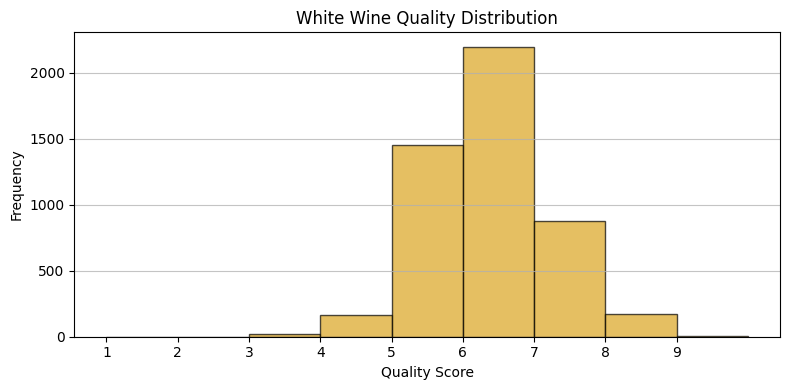

In [75]:
# @title 6. Quality Distribution Histogram
plt.figure(figsize=(8, 4))
plt.hist(df['quality'], bins=range(1, 11), edgecolor='black', color='#DAA520', alpha=0.7)
plt.title('White Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Frequency')
plt.xticks(range(1, 10))
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


In [76]:
# @title 7. Check And Handle Missing Data
missing = df.isnull().sum().sum()
print(f"Total Missing Values: {missing}")

df = df.dropna()
print(f"Dataset Shape After Cleaning: {df.shape}")


Total Missing Values: 0
Dataset Shape After Cleaning: (4898, 12)


In [91]:
# @title 8. Define INPUT And OUTPUT Variables
#
# INPUT Variables:  11 Physicochemical Features (Explanatory Variables)
# OUTPUT Variable:  Quality (Response Variable, Score Between 0 And 10)

output_variable = "quality"

# INPUT Features
all_features = [
    "fixed_acidity",        # 1
    "volatile_acidity",     # 2
    "citric_acid",          # 3
    "residual_sugar",       # 4
    "chlorides",            # 5
    "free_sulfur_dioxide",  # 6
    "total_sulfur_dioxide", # 7
    "density",              # 8
    "pH",                   # 9
    "sulphates",            # 10
    "alcohol"               # 11
]

print(f"Number Of INPUTS:  {len(all_features)}")
print(f"OUTPUT Variable:   {output_variable}")
print(f"\nAvailable Columns: {list(df.columns)}")


Number Of INPUTS:  11
OUTPUT Variable:   quality

Available Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


### 9. Model Development

| Keyword | Where In The Code |
|---|---|
| **INPUT** | `X_train`, `X_test` — 11 physicochemical features |
| **OUTPUT** | `y_train`, `y_test` — quality score |
| **MODEL** | `SGDRegressor` — linear regression trained via Gradient Descent |
| **LOSS FUNCTION** | Mean Squared Error (`squared_error`) — measures prediction error |
| **EPOCH** | One complete pass through the entire training dataset |
| **BATCH** | Mini-batch (batch size = 32) — model updates weights after every 32 samples |
| **TRAIN DATASET** | 80% of the data used to fit the model |
| **TEST DATASET** | 20% independent split, never seen during training |
| **PREDICT** | `model.predict()` generates predictions on the test set |


In [78]:
# @title 9. Split Into TRAIN DATASET And TEST DATASET (Independent)
X = df[all_features]       # INPUT Variables
y = df[output_variable]    # OUTPUT Variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"TRAIN DATASET: {X_train.shape[0]} Samples")
print(f"TEST DATASET:  {X_test.shape[0]} Samples (Independent)")


TRAIN DATASET: 3918 Samples
TEST DATASET:  980 Samples (Independent)


In [79]:
# @title 10. Scale The Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [80]:
# @title 11. Define The MODEL (SGDRegressor)
# MODEL: SGDRegressor — Linear Regression Via Gradient Descent
# LOSS FUNCTION: Mean Squared Error (Squared_Error)
# BATCH: Mini-Batch Gradient Descent — Updates Weights Every 32 Samples

batch_size = 32

model = SGDRegressor(
    loss="squared_error",        # LOSS FUNCTION: Mean Squared Error
    learning_rate="constant",
    eta0=0.00001,                 # Learning Rate (Low For Visible Convergence Curve)
    random_state=42,
    tol=None
)


In [81]:
# @title 12. Train The Model — Track LOSS Per EPOCH
# EPOCH: One Complete Pass Through The TRAIN DATASET
# BATCH: Mini-Batch (32 Samples Per Update)

n_epochs = 200
train_losses = []

for epoch in range(1, n_epochs + 1):
    # Shuffle The Data Each EPOCH
    indices = np.random.permutation(len(X_train_scaled))

    # Feed The Model One BATCH At A Time
    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        X_batch = X_train_scaled[batch_idx]
        y_batch = y_train.iloc[batch_idx]
        model.partial_fit(X_batch, y_batch)  # Update Weights On This BATCH

    # Record LOSS After Each Full EPOCH
    y_train_pred = model.predict(X_train_scaled)
    loss = mean_squared_error(y_train, y_train_pred)  # LOSS FUNCTION
    train_losses.append(loss)

print(f"Final Training LOSS (MSE): {train_losses[-1]:.4f}")


Final Training LOSS (MSE): 0.5652


In [82]:
# @title 13. PREDICT On Independent TEST DATASET
y_test_pred = model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"Test LOSS (MSE): {test_mse:.4f}")


Test LOSS (MSE): 0.5773


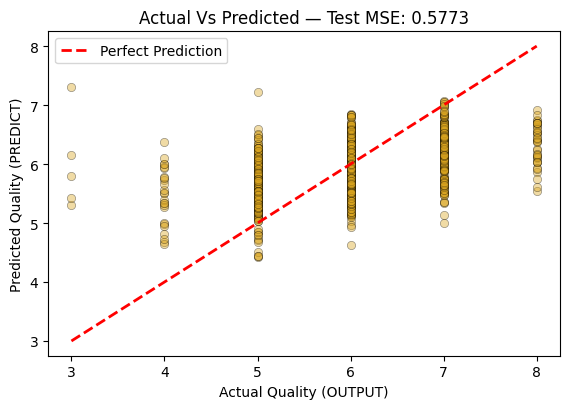

In [83]:
# @title 14. Actual Vs Predicted Values Of The Response Variable
plt.figure(figsize=(5.8, 4.2))
plt.scatter(y_test, y_test_pred,
            alpha=0.4, edgecolors='k', linewidths=0.5, color='#DAA520')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)
plt.xlabel('Actual Quality (OUTPUT)')
plt.ylabel('Predicted Quality (PREDICT)')
plt.title(f'Actual Vs Predicted — Test MSE: {test_mse:.4f}')
plt.legend()
plt.tight_layout()
plt.show()


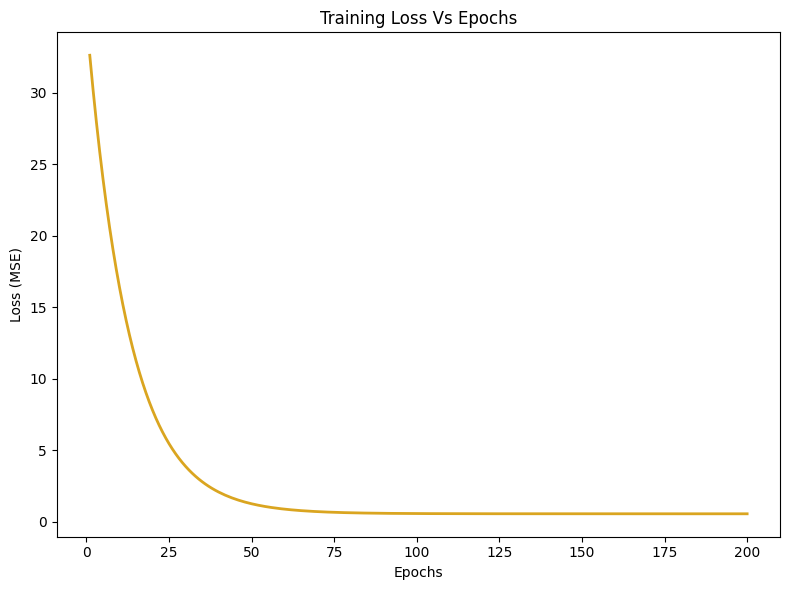

In [84]:
# @title 15. Loss Vs Epochs For Training
plt.figure(figsize=(8, 6))
plt.plot(range(1, n_epochs + 1), train_losses,
         linewidth=2, color='#DAA520')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Vs Epochs')
plt.tight_layout()
plt.show()


# Task
Create and save a GIF animation that visualizes the regression model's training progress. This animation will show, side-by-side for each epoch, the training loss reduction and the evolution of the model's predictions against actual values on the independent test set, including the Mean Squared Error for the current epoch.

## Initialize Animation Data Structures

### Subtask:
Create empty lists to store the training loss, predicted values on the test set, and test MSE for each epoch. These lists will accumulate data during the training process to be used for the animation.


**Reasoning**:
The subtask requires initializing several lists and variables to store data for animation. This code block will create the necessary empty lists and define the overall min and max for y-axis scaling.



In [85]:
train_losses_animation = []
y_test_preds_animation = []
test_mses_animation = []

y_min_overall = min(y_test.min(), y_test_pred.min())
y_max_overall = max(y_test.max(), y_test_pred.max())

print("Animation data structures initialized.")

Animation data structures initialized.


## Update Training Loop for Animation

### Subtask:
Modify the existing training loop (cell 'T_UkPzds1Ute') to calculate and record the training loss and the model's predictions on the independent test set along with its corresponding Mean Squared Error (MSE) at the end of each epoch. These metrics will be appended to the animation data structures.


**Reasoning**:
The subtask requires modifying the training loop to record epoch-wise metrics for animation. This involves re-initializing the model and then updating the loop to calculate and store the training loss, test predictions, and test MSE for each epoch in the previously initialized animation lists.



In [86]:
model = SGDRegressor(
    loss="squared_error",        # LOSS FUNCTION: Mean Squared Error
    learning_rate="constant",
    eta0=0.00001,                 # Learning Rate (Low For Visible Convergence Curve)
    random_state=42,
    tol=None
)

n_epochs = 200
train_losses = []

for epoch in range(1, n_epochs + 1):
    # Shuffle The Data Each EPOCH
    indices = np.random.permutation(len(X_train_scaled))

    # Feed The Model One BATCH At A Time
    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        X_batch = X_train_scaled[batch_idx]
        y_batch = y_train.iloc[batch_idx]
        model.partial_fit(X_batch, y_batch)  # Update Weights On This BATCH

    # Record LOSS After Each Full EPOCH
    y_train_pred_epoch = model.predict(X_train_scaled)
    train_loss_epoch = mean_squared_error(y_train, y_train_pred_epoch)  # LOSS FUNCTION
    train_losses.append(train_loss_epoch)
    train_losses_animation.append(train_loss_epoch)

    # Make predictions on the test set for this epoch
    y_test_pred_epoch = model.predict(X_test_scaled)
    y_test_preds_animation.append(y_test_pred_epoch.tolist()) # Append as list for consistent storage

    # Calculate Test MSE for this epoch
    test_mse_epoch = mean_squared_error(y_test, y_test_pred_epoch)
    test_mses_animation.append(test_mse_epoch)

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{n_epochs} - Training Loss: {train_loss_epoch:.4f} - Test MSE: {test_mse_epoch:.4f}")

print(f"Final Training LOSS (MSE): {train_losses[-1]:.4f}")
print(f"Final Test LOSS (MSE): {test_mses_animation[-1]:.4f}")

Epoch 50/200 - Training Loss: 1.2659 - Test MSE: 1.2870
Epoch 100/200 - Training Loss: 0.5818 - Test MSE: 0.5941
Epoch 150/200 - Training Loss: 0.5661 - Test MSE: 0.5780
Epoch 200/200 - Training Loss: 0.5652 - Test MSE: 0.5773
Final Training LOSS (MSE): 0.5652
Final Test LOSS (MSE): 0.5773


## Create Animation Function (Additional)



In [87]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def update_frame(frame):
    plt.clf()  # Clear the current figure

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Epoch {frame + 1}/{n_epochs}', fontsize=16)

    # Plot 1: Loss vs. Epochs
    ax1.plot(range(1, frame + 2), train_losses_animation[:frame + 1], linewidth=2, color='#DAA520')
    ax1.plot(frame + 1, train_losses_animation[frame], 'ro', markersize=8) # Mark current epoch
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_title('Training Loss Vs Epochs')
    ax1.set_xlim(0, n_epochs)
    # Set y-limit dynamically or with a reasonable upper bound from all losses
    ax1.set_ylim(0, max(train_losses_animation) * 1.1) # Max loss during training + 10% buffer
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Actual vs. Predicted
    current_y_test_pred = y_test_preds_animation[frame]
    current_test_mse = test_mses_animation[frame]

    ax2.scatter(y_test, current_y_test_pred,
                alpha=0.4, edgecolors='k', linewidths=0.5, color='#DAA520')
    ax2.plot(
        [y_min_overall, y_max_overall],
        [y_min_overall, y_max_overall],
        'r--', linewidth=2, label='Perfect Prediction'
    )
    ax2.set_xlabel('Actual Quality (OUTPUT)')
    ax2.set_ylabel('Predicted Quality (PREDICT)')
    ax2.set_title(f'Actual Vs Predicted - MSE: {current_test_mse:.4f}')
    ax2.set_xlim(y_min_overall, y_max_overall)
    ax2.set_ylim(y_min_overall, y_max_overall)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    return fig, ax1, ax2

print("Animation frame update function 'update_frame' defined.")

Animation frame update function 'update_frame' defined.


Generating GIF animation...


/tmp/ipykernel_652/347298829.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


GIF animation 'training_progress.gif' saved successfully.


<Figure size 640x480 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

...

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

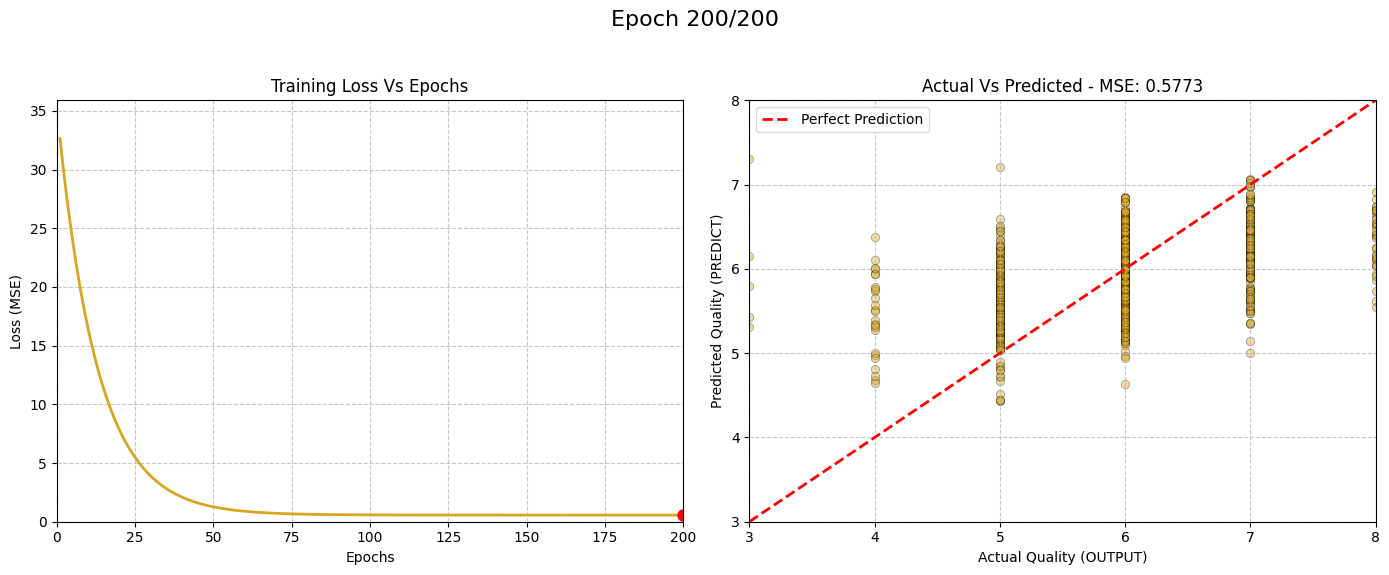

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.close(fig) # Prevent the initial blank plot from showing

animation_writer = animation.PillowWriter(fps=10)

print("Generating GIF animation...")

anim = animation.FuncAnimation(
    fig,
    update_frame,
    frames=n_epochs,
    blit=False,
    repeat=False,
    interval=50 # Milliseconds between frames
)

anim.save('training_progress.gif', writer=animation_writer)
print("GIF animation 'training_progress.gif' saved successfully.")

In [89]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def update_frame(frame, fig, ax1, ax2):
    ax1.clear()  # Clear content of ax1
    ax2.clear()  # Clear content of ax2

    fig.suptitle(f'Epoch {frame + 1}/{n_epochs}', fontsize=16)

    # Plot 1: Loss vs. Epochs
    ax1.plot(range(1, frame + 2), train_losses_animation[:frame + 1], linewidth=2, color='#DAA520')
    ax1.plot(frame + 1, train_losses_animation[frame], 'ro', markersize=8) # Mark current epoch
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_title('Training Loss Vs Epochs')
    ax1.set_xlim(0, n_epochs)
    ax1.set_ylim(0, max(train_losses_animation) * 1.1) # Max loss during training + 10% buffer
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Actual vs. Predicted
    current_y_test_pred = y_test_preds_animation[frame]
    current_test_mse = test_mses_animation[frame]

    ax2.scatter(y_test, current_y_test_pred,
                alpha=0.4, edgecolors='k', linewidths=0.5, color='#DAA520')
    ax2.plot(
        [y_min_overall, y_max_overall],
        [y_min_overall, y_max_overall],
        'r--', linewidth=2, label='Perfect Prediction'
    )
    ax2.set_xlabel('Actual Quality (OUTPUT)')
    ax2.set_ylabel('Predicted Quality (PREDICT)')
    ax2.set_title(f'Actual Vs Predicted - MSE: {current_test_mse:.4f}')
    ax2.set_xlim(y_min_overall, y_max_overall)
    ax2.set_ylim(y_min_overall, y_max_overall)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    # No return value needed for blit=False

print("Animation frame update function 'update_frame' defined (corrected).")


Animation frame update function 'update_frame' defined (corrected).


Generating GIF animation...
GIF animation 'training_progress.gif' saved successfully.


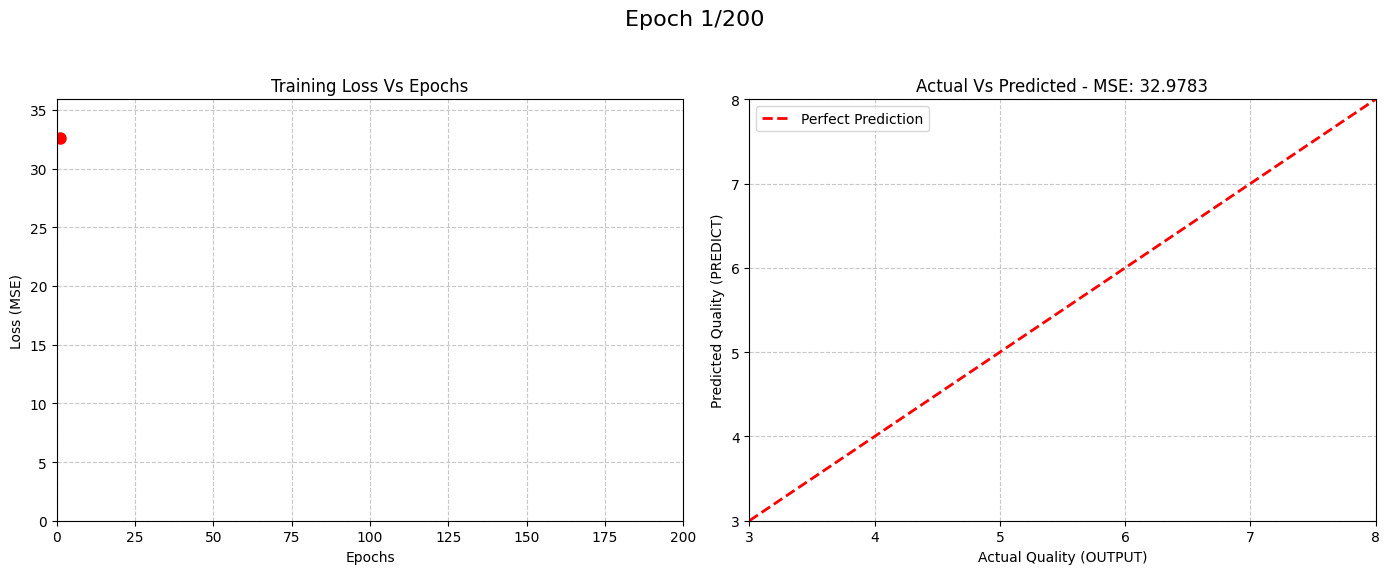

In [90]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.close(fig) # Prevent the initial blank plot from showing

animation_writer = animation.PillowWriter(fps=10)

print("Generating GIF animation...")

# Initialize the figure and axes outside the update_frame function
# and pass them as arguments using fargs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

anim = animation.FuncAnimation(
    fig,
    update_frame,
    frames=n_epochs,
    fargs=(fig, ax1, ax2), # Pass fig and axes to update_frame
    blit=False,
    repeat=False,
    interval=50 # Milliseconds between frames
)

anim.save('training_progress.gif', writer=animation_writer)
print("GIF animation 'training_progress.gif' saved successfully.")
